# Rafael TCC - Projeto 04
## Análise Estatística Descritiva

Análise Exploratória dos dados de touros Nelore presentes na plataforma CRV, segundo o programa de melhoramento

### Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### Leitura dos dados

In [2]:
programa = 'ANCP'
df_valid = pd.read_csv(f'Dados/CSV/NeloreCRV_{programa}_valido.csv')

### Análise selos comerciais da crv

In [3]:
# PASSO 1: Identificar todos os selos únicos
selos = set()
for item in df_valid['SELOS'].dropna():
    selos_linha = [s.strip().lower() for s in str(item).split(';') if s.strip()]
    selos.update(selos_linha)

selos = set(map(str.upper, selos))
selos = sorted(list(selos))

print(f"Total de selos identificados: {len(selos)}")
print("Selos encontrados:", selos)

Total de selos identificados: 16
Selos encontrados: ['ATJ-PLUS', 'CAR', 'CARCACA-3-ESTRELAS', 'CARCACA-4-ESTRELAS', 'CARCACA-5-ESTRELAS', 'EXTENSIVO', 'IFERT', 'MATERNAL', 'NOVILHAS', 'PESO', 'PNAT', 'PO', 'REPRODUTIVO', 'RP-ANCP', 'SEMIEXTENSIVO', 'SEMIINTENSIVO']


In [4]:
# Criar novo dataframe com colunas de 1 ou 0 para cada selo
df_selos = df_valid[['CRV_COD', 'NOME', 'RACA', 'RGD', 'DNASC', 'SEMEM']].copy()

for selo in selos:
    # Nome padronizado para a coluna: ex: SELO_IFERT, SELO_CARCACA_5_ESTRELAS
    nome_coluna = 'SELO_' + selo.replace('-', '_')
    
    # Preenche com 1 se o selo estiver no texto da coluna, 0 caso contrário
    df_selos[nome_coluna] = df_valid['SELOS'].apply(
        lambda x: 1 if pd.notna(x) and selo in [s.strip().upper() for s in str(x).split(';')] else 0
    )

In [5]:
# Frequência dos selos e Preço Médio por presença do selo

colunas_selos = [c for c in df_selos.columns if c.startswith('SELO_')]

resumo_selos = []
for col in colunas_selos:
    n_com = (df_selos[col] == 1).sum()
    pct_com = (n_com / len(df_selos)) * 100
    media_com = df_selos.loc[df_selos[col] == 1, 'SEMEM'].mean()
    media_sem = df_selos.loc[df_selos[col] == 0, 'SEMEM'].mean()
    dif_preco = media_com - media_sem
    
    resumo_selos.append({
        'Selo': col,
        'N_Touros': n_com,
        '% Touros': round(pct_com, 1),
        'Preço Médio COM (R$)': round(media_com, 2),
        'Preço Médio SEM (R$)': round(media_sem, 2),
        'Diferença (R$)': round(dif_preco, 2)
    })

df_resumo = pd.DataFrame(resumo_selos).sort_values(by='N_Touros', ascending=False)
df_resumo.reset_index(drop=True, inplace=True)
df_resumo


,Selo,N_Touros,% Touros,Preço Médio COM (R$),Preço Médio SEM (R$),Diferença (R$)
0,SELO_PO,115,100.0,32.40,NaN,NaN
1,SELO_PESO,96,83.5,32.31,32.85,-0.53
2,SELO_REPRODUTIVO,80,69.6,32.36,32.50,-0.14
3,SELO_MATERNAL,76,66.1,33.15,30.95,2.20
4,SELO_SEMIINTENSIVO,62,53.9,32.24,32.58,-0.34
5,SELO_CAR,56,48.7,33.36,31.49,1.86
6,SELO_SEMIEXTENSIVO,51,44.3,32.36,32.43,-0.07
7,SELO_IFERT,46,40.0,35.90,30.07,5.84
8,SELO_CARCACA_5_ESTRELAS,42,36.5,33.64,31.69,1.95
9,SELO_CARCACA_4_ESTRELAS,32,27.8,32.09,32.52,-0.43


#### Avaliação de ágio de preço por selo comercial (com selo vs sem selo)

In [6]:
# Calcular o Ágio para cada selo (mínimo de 5 touros com o selo para ter validade)
colunas_selos = [c for c in df_selos.columns if c.startswith('SELO_')]

resultados_selos = []

for selo in colunas_selos:
    com_selo = df_selos[df_selos[selo] == 1]['SEMEM']
    sem_selo = df_selos[df_selos[selo] == 0]['SEMEM']
    
    n_com = len(com_selo)
    n_sem = len(sem_selo)
    
    # Considerar apenas selos com representatividade mínima (>= 5 animais)
    if n_com >= 5 and n_sem >= 5:
        media_com = com_selo.mean()
        media_sem = sem_selo.mean()
        mediana_com = com_selo.median()
        mediana_sem = sem_selo.median()
        
        agio_reais = media_com - media_sem
        agio_pct = ((media_com / media_sem) - 1) * 100
        
        # Teste t de Student para testar diferença estatística entre as médias
        t_stat, p_val = stats.ttest_ind(com_selo, sem_selo, equal_var=False)
        
        resultados_selos.append({
            'Selo Comercial': selo.upper(),
            'N_Com_Selo': n_com,
            'N_Sem_Selo': n_sem,
            'Preço Médio COM (R$)': round(media_com, 2),
            'Preço Médio SEM (R$)': round(media_sem, 2),
            'Mediana COM (R$)': round(mediana_com, 2),
            'Mediana SEM (R$)': round(mediana_sem, 2),
            'Ágio (R$)': round(agio_reais, 2),
            'Ágio (%)': round(agio_pct, 1),
            'p-valor': round(p_val, 4)
        })

df_agio_selos = pd.DataFrame(resultados_selos).sort_values(by='Ágio (R$)', ascending=False).reset_index(drop=True)

# Adicionar formatação de significância
def rotulo_p(p):
    if p < 0.01: return '*** (Signif. 1%)'
    if p < 0.05: return '** (Signif. 5%)'
    if p < 0.10: return '* (Signif. 10%)'
    return 'Não significativo'

df_agio_selos['Significância'] = df_agio_selos['p-valor'].apply(rotulo_p)

print("=" * 100)
print("RANKING DE VALORIZAÇÃO DOS SELOS COMERCIAIS NA CRV (ÁGIO: COM SELO vs SEM SELO)")
print("=" * 100)
display(df_agio_selos)

RANKING DE VALORIZAÇÃO DOS SELOS COMERCIAIS NA CRV (ÁGIO: COM SELO vs SEM SELO)


,Selo Comercial,N_Com_Selo,N_Sem_Selo,Preço Médio COM (R$),Preço Médio SEM (R$),Mediana COM (R$),Mediana SEM (R$),Ágio (R$),Ágio (%),p-valor,Significância
0,SELO_IFERT,46,69,35.90,30.07,33.9,31.2,5.84,19.4,0.0000,*** (Signif. 1%)
1,SELO_NOVILHAS,29,86,34.18,31.80,33.9,31.2,2.38,7.5,0.1140,Não significativo
2,SELO_MATERNAL,76,39,33.15,30.95,31.2,31.2,2.20,7.1,0.0801,* (Signif. 10%)
3,SELO_CARCACA_5_ESTRELAS,42,73,33.64,31.69,31.2,31.2,1.95,6.1,0.1299,Não significativo
4,SELO_CAR,56,59,33.36,31.49,31.8,31.2,1.86,5.9,0.1416,Não significativo
5,SELO_RP_ANCP,7,108,33.40,32.34,31.2,31.2,1.06,3.3,0.6720,Não significativo
6,SELO_SEMIEXTENSIVO,51,64,32.36,32.43,31.2,31.2,-0.07,-0.2,0.9553,Não significativo
7,SELO_REPRODUTIVO,80,35,32.36,32.50,31.2,33.9,-0.14,-0.4,0.9238,Não significativo
8,SELO_SEMIINTENSIVO,62,53,32.24,32.58,31.2,31.2,-0.34,-1.0,0.7902,Não significativo
9,SELO_CARCACA_4_ESTRELAS,32,83,32.09,32.52,31.2,31.2,-0.43,-1.3,0.7812,Não significativo


#### Gráfico de barras: ágio de preço por selo comercial

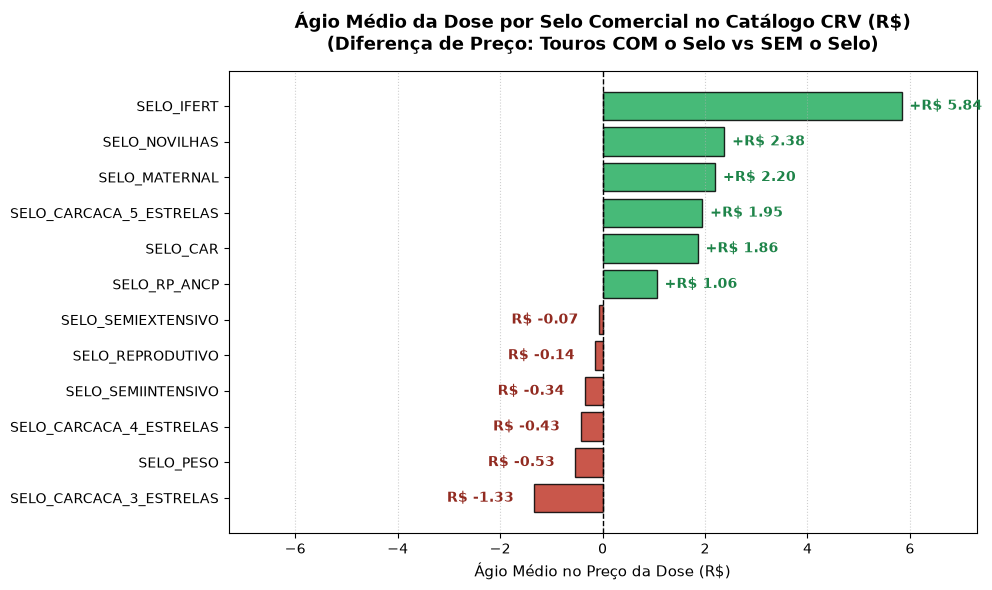

In [7]:
plt.figure(figsize=(10, 6))

cores_graf = ['#27ae60' if x >= 0 else '#c0392b' for x in df_agio_selos['Ágio (R$)'][::-1]]
barras = plt.barh(df_agio_selos['Selo Comercial'][::-1], df_agio_selos['Ágio (R$)'][::-1], 
                  color=cores_graf, edgecolor='black', alpha=0.85)

for b in barras:
    w = b.get_width()
    sinal = "+" if w >= 0 else ""
    plt.text(w + (0.15 if w>=0 else -0.4), b.get_y() + b.get_height()/2, f"{sinal}R$ {w:.2f}", 
             va='center', ha='left' if w>=0 else 'right', fontsize=10, fontweight='bold', 
             color='#1e8449' if w>=0 else '#922b21')

plt.title("Ágio Médio da Dose por Selo Comercial no Catálogo CRV (R$)\n(Diferença de Preço: Touros COM o Selo vs SEM o Selo)", 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Ágio Médio no Preço da Dose (R$)", fontsize=11)
lim_x = max(abs(df_agio_selos['Ágio (R$)'].min()), abs(df_agio_selos['Ágio (R$)'].max())) * 1.25
plt.xlim(-lim_x, lim_x)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Regressão multivariada com selos comerciais

In [8]:
# 1. Seleção das variáveis líderes apontadas pelo Random Forest
variaveis_modelo = [
    'SELO_IFERT',
    'SELO_CARCACA_5_ESTRELAS',
    'SELO_NOVILHAS',    
    'SELO_CAR',
    'SELO_MATERNAL',
    'SELO_RP_ANCP'
]

# Preparar base de regressão sem dados faltantes nas variáveis do modelo
df_reg = df_selos.dropna(subset=['SEMEM'] + variaveis_modelo).copy()
print(f"Número de observações válidas utilizadas na Regressão: N = {len(df_reg)}")

# 2. Definição de X (adicionando a constante/intercepto) e y
X_ols = df_reg[variaveis_modelo].copy()
X_ols_com_constante = sm.add_constant(X_ols)
y_ols = df_reg['SEMEM'].copy()

# 3. Ajuste do Modelo de Mínimos Quadrados Ordinários (OLS)
modelo_ols = sm.OLS(y_ols, X_ols_com_constante).fit()

# 4. Tabela de Coeficientes Formatada com Nível de Significância
tabela_coef = pd.DataFrame({
    'Coeficiente (Beta R$)': modelo_ols.params.round(3),
    'Erro Padrão': modelo_ols.bse.round(3),
    'Estatística t': modelo_ols.tvalues.round(2),
    'p-valor': modelo_ols.pvalues.round(4)
})

# Adicionar estrelas de significância acadêmica
def formatar_significancia(p):
    if p < 0.01: return '*** (Signif. a 1%)'
    if p < 0.05: return '** (Signif. a 5%)'
    if p < 0.10: return '* (Signif. a 10%)'
    return 'Não significativo'

tabela_coef['Significância'] = tabela_coef['p-valor'].apply(formatar_significancia)

# Renomear os índices para exibição bonita
nomes_legiveis = {
    'SELO_IFERT': 'FERTILIDADE',
    'SELO_CARCACA_5_ESTRELAS': 'QUALIDADE DE CARCAÇA',
    'SELO_NOVILHAS': 'NOVILHAS',    
    'SELO_CAR': 'EFICIENCIA ALIMENTAR',
    'SELO_MATERNAL': 'HABILIDADE MATERNA',
    'SELO_RP_ANCP': 'SELO ANCP'
}
tabela_coef.index = [nomes_legiveis.get(i, i) for i in tabela_coef.index]

print("=" * 85)
print(f"RESULTADOS DA REGRESSÃO HEDÔNICA MULTIVARIADA (R² = {modelo_ols.rsquared:.3f} | R² Ajustado = {modelo_ols.rsquared_adj:.3f})")
print(f"Estatística F = {modelo_ols.fvalue:.2f} (p-valor do Modelo = {modelo_ols.f_pvalue:.4e})")
print("=" * 85)
display(tabela_coef)

Número de observações válidas utilizadas na Regressão: N = 115
RESULTADOS DA REGRESSÃO HEDÔNICA MULTIVARIADA (R² = 0.242 | R² Ajustado = 0.200)
Estatística F = 5.74 (p-valor do Modelo = 3.2568e-05)


,Coeficiente (Beta R$),Erro Padrão,Estatística t,p-valor,Significância
const,27.093,1.281,21.14,0.0000,*** (Signif. a 1%)
FERTILIDADE,5.667,1.179,4.81,0.0000,*** (Signif. a 1%)
QUALIDADE DE CARCAÇA,1.746,1.198,1.46,0.1479,Não significativo
NOVILHAS,1.616,1.324,1.22,0.2250,Não significativo
EFICIENCIA ALIMENTAR,1.079,1.147,0.94,0.3488,Não significativo
HABILIDADE MATERNA,2.279,1.209,1.89,0.0620,* (Signif. a 10%)
SELO ANCP,-0.575,2.415,-0.24,0.8122,Não significativo


#### Diagnóstico de multicolinearidade (VIF - variance inflation factor)

In [9]:
vif_data = pd.DataFrame()
vif_data['Característica'] = [nomes_legiveis.get(c, c) for c in variaveis_modelo]
vif_data['VIF'] = [variance_inflation_factor(X_ols.values, i) for i in range(X_ols.shape[1])]
vif_data['VIF'] = vif_data['VIF'].round(2)
vif_data['Diagnóstico'] = vif_data['VIF'].apply(lambda x: 'Excelente (< 5)' if x < 5 else ('Aceitável (< 10)' if x < 10 else 'Alerta (> 10)'))

print("\n" + "=" * 85)
print("DIAGNÓSTICO DE MULTICOLINEARIDADE (VIF)")
print("=" * 85)
display(vif_data)


DIAGNÓSTICO DE MULTICOLINEARIDADE (VIF)


,Característica,VIF,Diagnóstico
0,FERTILIDADE,1.04,Excelente (< 5)
1,QUALIDADE DE CARCAÇA,1.04,Excelente (< 5)
2,NOVILHAS,1.03,Excelente (< 5)
3,EFICIENCIA ALIMENTAR,1.02,Excelente (< 5)
4,HABILIDADE MATERNA,1.02,Excelente (< 5)
5,SELO ANCP,1.04,Excelente (< 5)


EFEITO DEGRAU: VALORIZAÇÃO POR ACÚMULO DE SELOS COMERCIAIS


,TOTAL_SELOS,N_Touros,Preco_Medio,Preco_Mediano
1,4,15,27.42,24.8
2,5,9,31.63,33.9
3,6,32,31.23,31.2
4,7,36,33.61,33.9
5,8,14,35.41,33.9
6,9,7,35.70,33.9


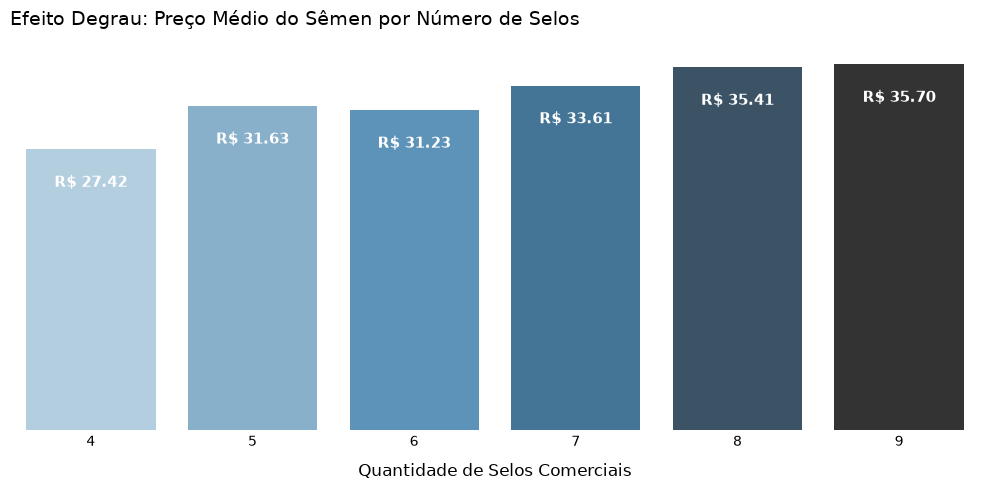


REGRESSÃO LINEAR: EFEITO MARGINAL DO ACÚMULO DE SELOS (R² = 0.122)
p-valor do modelo = 1.5218e-04
Coeficiente (Beta): R$ 1.74 por selo adicional
P-valor: 0.0002

CONCLUSÃO: O mercado paga estatisticamente um prêmio de R$ 1.74 por CADA selo adicional que o touro possua.


In [10]:
# 1. Criar a variável com a contagem total de selos por touro
colunas_selos = [c for c in df_selos.columns if c.startswith('SELO_')]
df_selos['TOTAL_SELOS'] = df_selos[colunas_selos].sum(axis=1)

# 2. Tabela Descritiva: Preço médio e mediano por Quantidade de Selos
tabela_degrau = df_selos.groupby('TOTAL_SELOS').agg(
    N_Touros=('SEMEM', 'count'),
    Preco_Medio=('SEMEM', 'mean'),
    Preco_Mediano=('SEMEM', 'median')
).reset_index()

# Filtrar apenas grupos com pelo menos 3 touros para evitar distorções estatísticas
tabela_degrau = tabela_degrau[tabela_degrau['N_Touros'] >= 3].round(2)

print("=" * 80)
print("EFEITO DEGRAU: VALORIZAÇÃO POR ACÚMULO DE SELOS COMERCIAIS")
print("=" * 80)
display(tabela_degrau)

# 3. Gráfico para visualizar o Efeito Degrau
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=tabela_degrau, 
    x='TOTAL_SELOS', 
    y='Preco_Medio', 
    hue='TOTAL_SELOS',
    palette='Blues_d',
    legend=False
)

# Rótulos de dados posicionados na borda superior interna das barras
for i, row in enumerate(tabela_degrau.itertuples()):
    y_pos = row.Preco_Medio - 2.5
    ax.text(
        i, 
        y_pos, 
        f'R$ {row.Preco_Medio:.2f}', 
        ha='center', 
        va='top', 
        color='white', 
        fontsize=11, 
        fontweight='bold'
    )

# --- LIMPEZA VISUAL (Storytelling com Dados) ---
# 1. Remove todas as bordas e a linha do eixo X
sns.despine(top=True, right=True, left=True, bottom=True)

# 2. Remove valores e título do eixo Y (os rótulos dentro das barras já informam o valor)
ax.set_ylabel('')
ax.set_yticks([])

# 3. Remove os tracinhos/marcadores do eixo X, mantendo o rótulo descritivo
ax.tick_params(axis='x', length=0)
ax.set_xlabel('Quantidade de Selos Comerciais', fontsize=12, labelpad=10)

# Título limpo e alinhado à esquerda
plt.title('Efeito Degrau: Preço Médio do Sêmen por Número de Selos', fontsize=14, loc='left', pad=15)
plt.tight_layout()
plt.show()

# 4. Regressão OLS do Efeito Degrau (Preço = B0 + B1 * Total_Selos)
df_reg_degrau = df_selos.dropna(subset=['SEMEM', 'TOTAL_SELOS']).copy()

# Apenas touros que entram na nossa tabela filtrada de representatividade
val_aceitos = tabela_degrau['TOTAL_SELOS'].tolist()
df_reg_degrau = df_reg_degrau[df_reg_degrau['TOTAL_SELOS'].isin(val_aceitos)]

X_degrau = df_reg_degrau[['TOTAL_SELOS']]
X_degrau_const = sm.add_constant(X_degrau)
y_degrau = df_reg_degrau['SEMEM']

modelo_degrau = sm.OLS(y_degrau, X_degrau_const).fit()

print("\n" + "=" * 80)
print(f"REGRESSÃO LINEAR: EFEITO MARGINAL DO ACÚMULO DE SELOS (R² = {modelo_degrau.rsquared:.3f})")
print(f"p-valor do modelo = {modelo_degrau.f_pvalue:.4e}")
print("=" * 80)

beta_degrau = modelo_degrau.params['TOTAL_SELOS']
p_val_degrau = modelo_degrau.pvalues['TOTAL_SELOS']

print(f"Coeficiente (Beta): R$ {beta_degrau:.2f} por selo adicional")
print(f"P-valor: {p_val_degrau:.4f}")

if p_val_degrau < 0.05:
    print(f"\nCONCLUSÃO: O mercado paga estatisticamente um prêmio de R$ {beta_degrau:.2f} por CADA selo adicional que o touro possua.")
else:
    print("\nCONCLUSÃO: A quantidade total de selos não possui significância estatística linear forte sobre o preço nesta amostragem.")


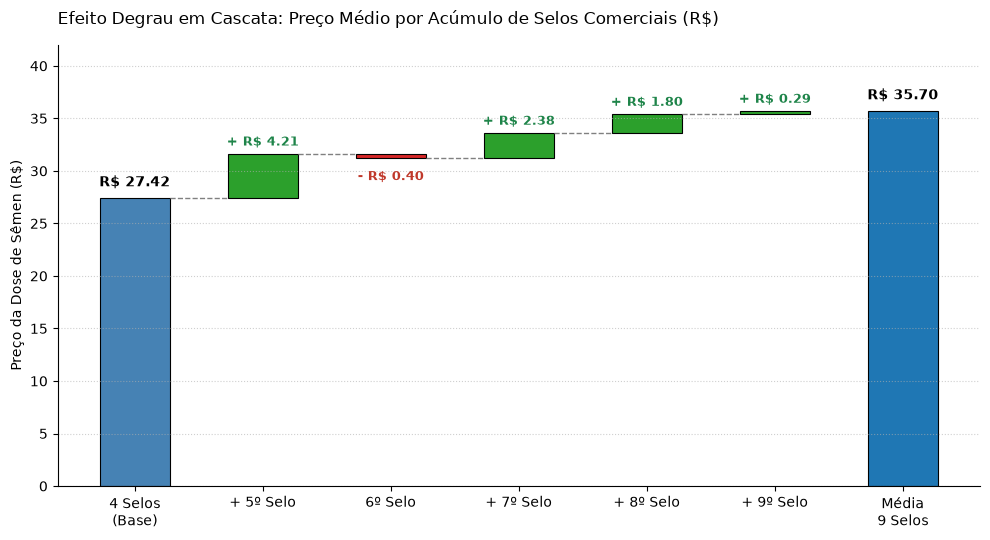

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Dados reais exatamente iguais à imagem do Caderno 07:
categorias = ['4 Selos\n(Base)', '+ 5º Selo', '6º Selo', '+ 7º Selo', '+ 8º Selo', '+ 9º Selo', 'Média\n9 Selos']

# Saltos marginais reais entre cada quantidade de selos:
# 4 selos: 27.42
# 5 selos: 31.63 (+4.21)
# 6 selos: 31.23 (-0.40)
# 7 selos: 33.61 (+2.38)
# 8 selos: 35.41 (+1.80)
# 9 selos: 35.70 (+0.29)

bottoms = [0, 27.42, 31.23, 31.23, 33.61, 35.41, 0]
alturas = [27.42, 4.21, 0.40, 2.38, 1.80, 0.29, 35.70]
cores = ['#4682b4', '#2ca02c', '#d62728', '#2ca02c', '#2ca02c', '#2ca02c', '#1f77b4']

plt.figure(figsize=(10, 5.5))
ax = plt.subplot(111)

barras = ax.bar(categorias, alturas, bottom=bottoms, color=cores, width=0.55, edgecolor='black', linewidth=0.8)

# Linhas conectoras entre os degraus
conexoes = [
    (0, 1, 27.42),
    (1, 2, 31.63),
    (2, 3, 31.23),
    (3, 4, 33.61),
    (4, 5, 35.41)
]
for x1, x2, y in conexoes:
    ax.plot([x1 + 0.275, x2 - 0.275], [y, y], color='gray', linestyle='--', linewidth=1)

# Rótulos em cada barra
for i, bar in enumerate(barras):
    h = bar.get_height()
    b = bar.get_y()
    
    if i == 0 or i == 6:
        # Colunas de Base e Total
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f"R$ {h:.2f}", 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    elif i == 2:
        # Queda leve no 6º selo (-0.40)
        ax.text(bar.get_x() + bar.get_width()/2, b - 1.2, f"- R$ {h:.2f}", 
                ha='center', va='top', fontsize=9, fontweight='bold', color='#c0392b')
    else:
        # Ganhos positivos (+)
        ax.text(bar.get_x() + bar.get_width()/2, b + h + 0.5, f"+ R$ {h:.2f}", 
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1e8449')

ax.set_ylim(0, 42)
ax.set_title('Efeito Degrau em Cascata: Preço Médio por Acúmulo de Selos Comerciais (R$)', fontsize=12, loc='left', pad=15)
ax.set_ylabel('Preço da Dose de Sêmen (R$)', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.6)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()
